In [11]:
# %load_ext autoreload
# %autoreload 2
from matplotlib import pyplot as plt
from matplotlib import pylab as pl
import matplotlib as mpl
import cmcrameri.cm as cmc
from matplotlib import rcParams
import numpy as np
import pandas as pd
from scipy.io import loadmat

# import sys
# sys.path.insert(0, "../sliptools")
# from statData import StatData
from helpers import *

# nu = 1.8e-5

# Slip parameter sweep
with data from stat files (text)

## methods of measuring $u_\ast$

In [8]:
case_info = pd.read_excel('data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U15_HS12_kp07', 'U18_HS12_kp07', 'U21_HS12_kp07', 'U24_HS12_kp07']
ids = [r'$U_0$ = 15 m/s', r'$U_0$ = 18 m/s',
       r'$U_0$ = 21 m/s', r'$U_0$ = 24 m/s']
colors = ['#b2dfe3','#96afce','#807FB3', 'navy']

# cases = ['U24_HS12_kp07', 'U24_just_steady']
# ids = ['origina U24', 'U24 just steady']
# colors = ['navy','dodgerblue']

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

# * swell cases
swell_caseids = [case+'_swell/'+case+'_swell' for case in cases]
swell_ids = [id+' swell' for id in ids]
swell_statlist = make_statlist(swell_caseids, swell_ids, case_info)

$U_0$ = 15 m/s swell
U(20): 10.6

$U_0$ = 18 m/s swell
U(20): 12.3

$U_0$ = 21 m/s swell
U(20): 14.4

$U_0$ = 24 m/s swell
U(20): 16.3

$U_0$ = 15 m/s
U(20): 10.2

$U_0$ = 18 m/s
U(20): 12.2

$U_0$ = 21 m/s
U(20): 14.2

$U_0$ = 24 m/s
U(20): 16.0



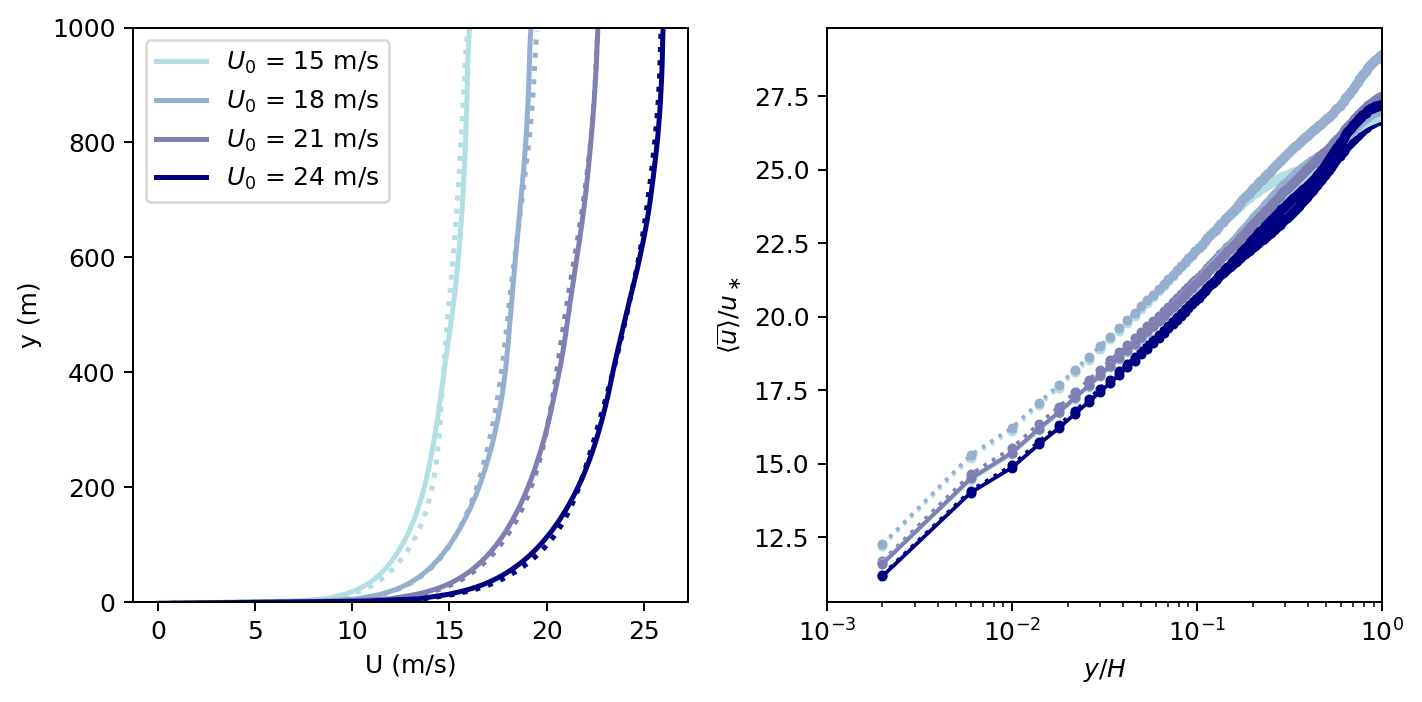

In [9]:
fig, axs = plt.subplots(1,2,facecolor='w', dpi=180.0, tight_layout=True, figsize=(8,4))

plot_velocity(swell_statlist, swell_ids, colors, linestyle=':', axs=axs, labels=False)
plot_velocity(statlist, ids, colors, axs=axs)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


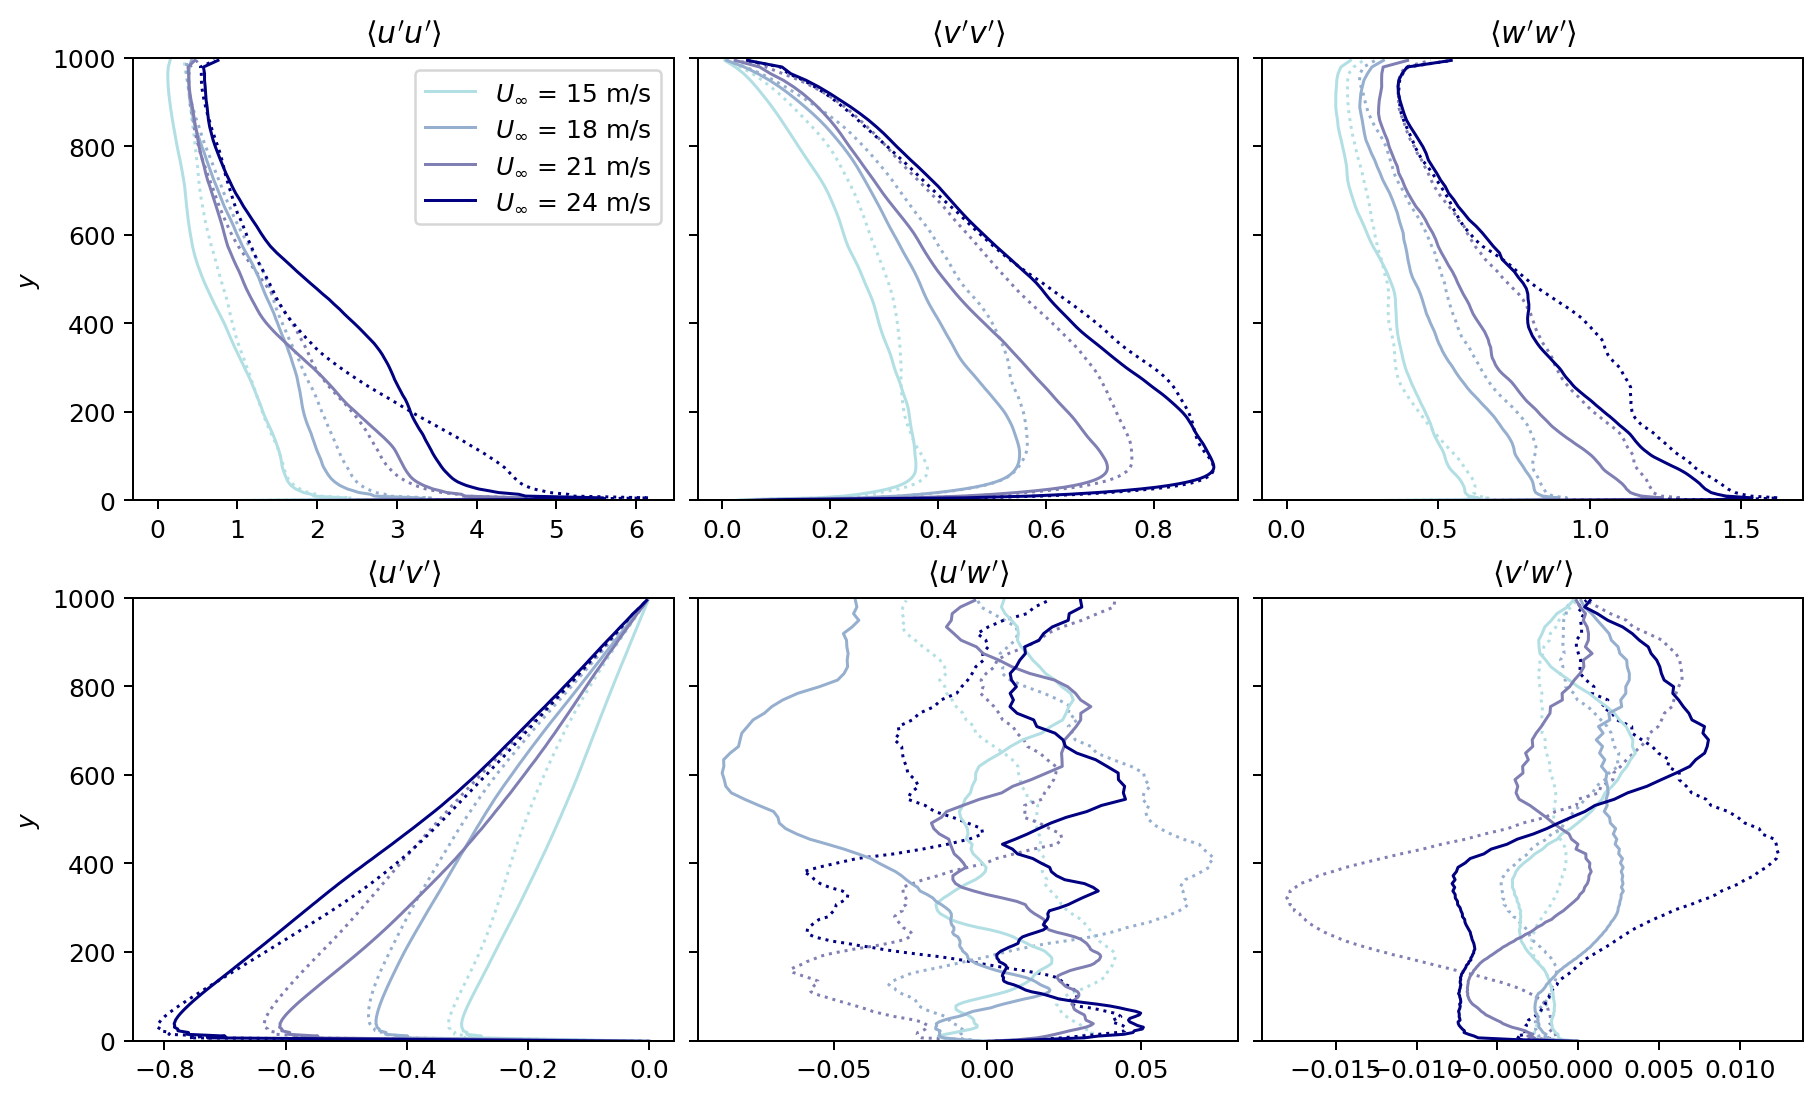

In [41]:
fig, axs = plt.subplots(2, 3, facecolor='w', dpi=180, constrained_layout=True,
                                figsize=(10,6), sharey=True)

plot_reynolds(swell_statlist, swell_ids, colors, linestyle=':', fig=fig, axs=axs, labels=False)
plot_reynolds(statlist, ids, colors, fig=fig, axs=axs)

profiles for the paper

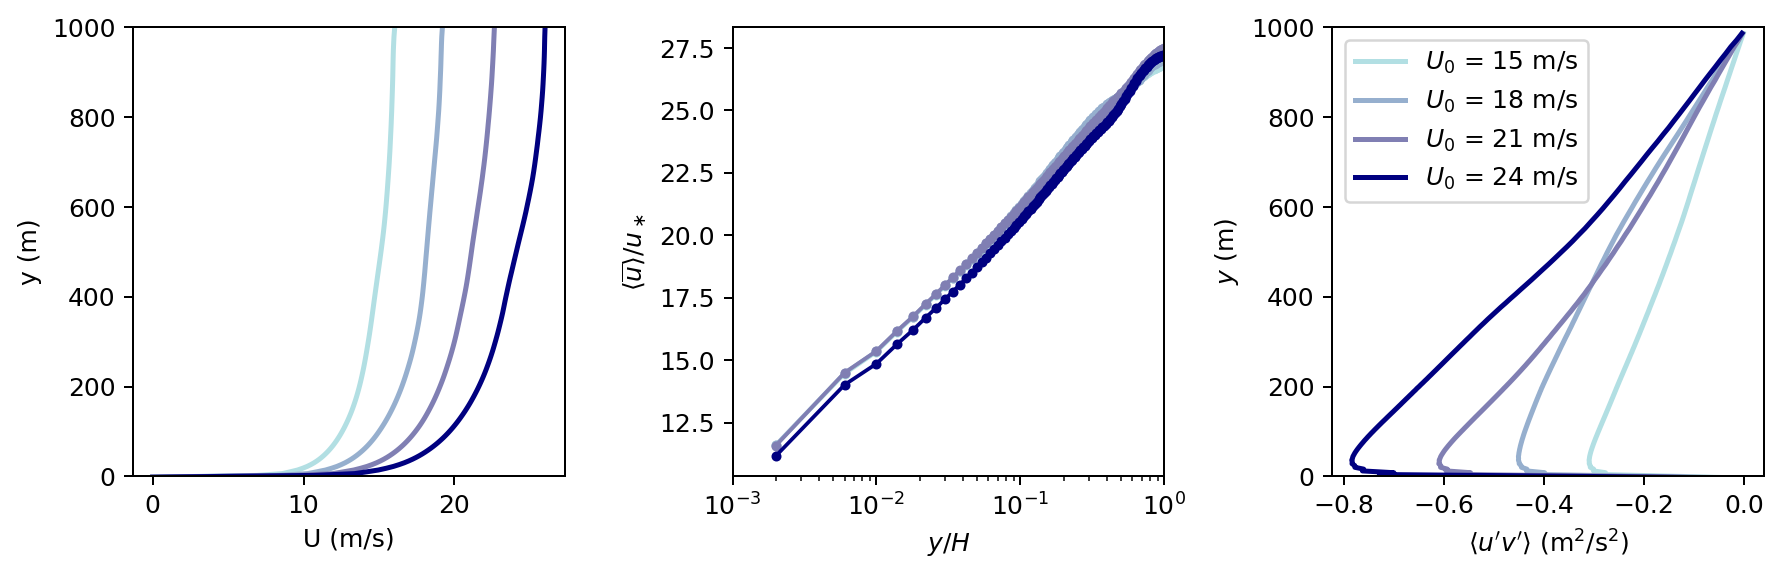

In [6]:
fig, axs = plt.subplots(1,3,facecolor='w', dpi=180.0, tight_layout=True, figsize=(10,3.3))

plot_velocity(statlist, ids, colors, axs=axs[0:2], labels=False)
plot_upvp(statlist, ids, colors, ax=axs[2], labels=True)

# axs[2].axhline(y=10, color='red', lw=0.3)

fig.savefig('figures/profiles.pdf')

/tmp/ipykernel_1868749/3310594787.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=10, marker='x', lw=1,


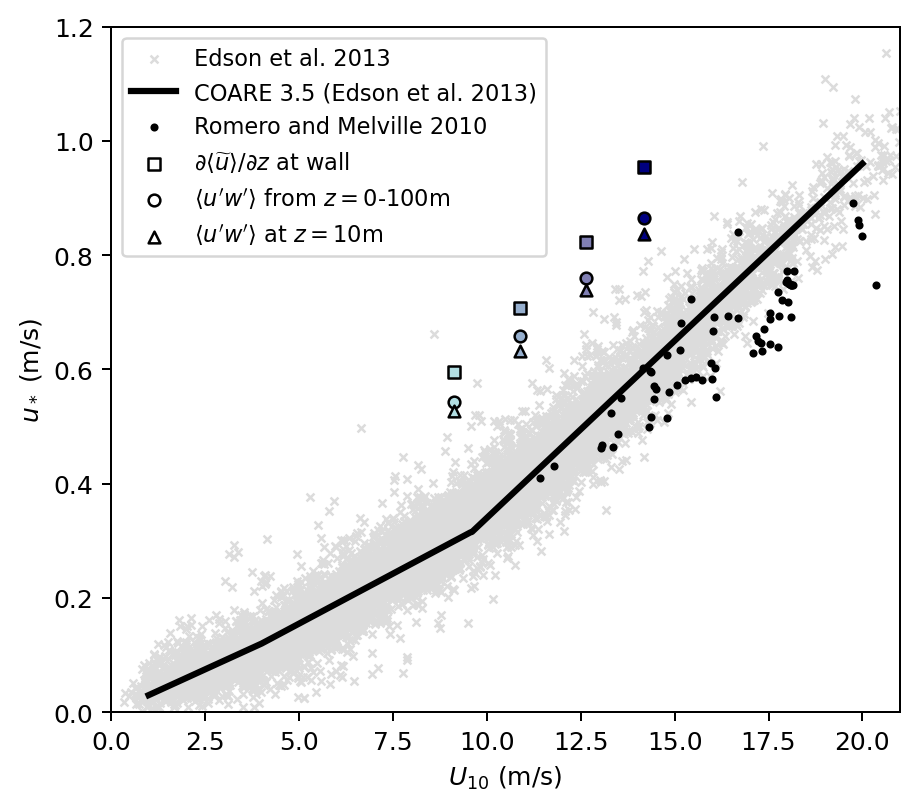

In [8]:

ustar_dudy = [stat.ustar for stat in statlist.values()]
ustar_200m = [stat.flux_ustar([0,100]) for stat in statlist.values()]
ustar_10m = [stat.flux_ustar([10]) for stat in statlist.values()]
ustars = ustar_dudy + ustar_200m + ustar_10m
u10_one = [stat.Uz(10) for stat in statlist.values()]
u10s = u10_one + u10_one + u10_one

colors = ['#b2dfe3', '#96afce','#807FB3','navy',
          '#b2dfe3', '#96afce','#807FB3','navy',
          '#b2dfe3', '#96afce','#807FB3','navy']
labels = [r'$\partial\langle\widetilde{u}\rangle /\partial z$ at wall',
          #r'$\frac{\partial\langle\widetilde{u}\rangle}{\partial z}$ at wall', 
          r"$\langle u'w' \rangle$ from $z=$0-100m", 
          r"$\langle u'w'\rangle$ at $z=$10m"]
markers = ['s','o','^']

# plot_coare(ustars, u10s, colors, markers, labels)
fig, ax = coare_plot_starter(figsize=(5.2, 4.6), Romero_cmap='none')

for i, (x, y) in enumerate(zip(u10s, ustars)):
    marker = markers[int(i/len(colors)*len(markers))] # * same marker
    ax.scatter(x, y, color=colors[i], marker=marker, edgecolors='black', s=22, zorder=3)

for marker, label in zip(markers, labels):
    ax.scatter([], [], color='white', edgecolors='black', marker=marker, s=22, label=label)

ax.legend(fontsize=9)

fig.savefig('figures/slip_coare_uinf_all_ustar.pdf')

## parameter sweep

### Color wave cases by different nondim parameters

In [12]:
wave_cases = ['U18_HS04_kp07', 'U18_HS12_kp04', 'U18_HS12_kp07', 'U18_HS12_kp16',
              'U18_HS20_kp07']
wave_ids = ['hs04', 'kp04', 'mid', 'kp16', 'hs20']
wind_cases = ['U15_HS12_kp07', 'U18_HS12_kp07', 'U21_HS12_kp07', 'U24_HS12_kp07']
wind_ids = ['U15','U18','U21','U24']

wave_caseids = [case+'_swell/'+case+'_swell' for case in wave_cases]
wind_caseids = [case+'_swell/'+case+'_swell' for case in wind_cases]

case_info = pd.read_excel('data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)
wave_stats = make_statlist(wave_caseids, wave_ids, case_info)
wind_stats = make_statlist(wind_caseids, wind_ids, case_info)

# * parameters
g= 9.81
z_us = [10] #[0,100] 

# * wave cases
kps = [0.0785, 0.0393, 0.0785, 0.157, 0.0785]
hses = [0.4, 1.2, 1.2, 1.2, 2.0]
cps = [np.sqrt(g/kp) for kp in kps]
wave_ustars = [stat.flux_ustar(z_us) for stat in wave_stats.values()]
wave_u10s = [stat.Uz(10) for stat in wave_stats.values()]

# * wind cases
wind_ustars = [stat.flux_ustar(z_us) for stat in wind_stats.values()]
wind_u10s = [stat.Uz(10) for stat in wind_stats.values()]

In [13]:

# * kpHs
wave_colors = [kps[i]*hses[i] for i in range(len(wave_cases))]

colorparamid = r'$k_pH_s$'
wave_cmap = cmc.acton

# * cp/u*
# colorparams = [cps[i]*ustars[i] for i in range(len(wave_cases))]
# colorparamid = r'$c_p/u_\ast$'

# * wind
wind_colors = [15, 18, 21, 24]
wind_cmap = cmc.navia

wind_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'Blues_truncated',
        wind_cmap(np.linspace(0, 0.85, 256))
)

/home/hhwilliams/Documents/spectrum_farm/slip-subgrid-wave-drag/parameter_sweep/helpers.py:150: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=10, marker='x', lw=1,


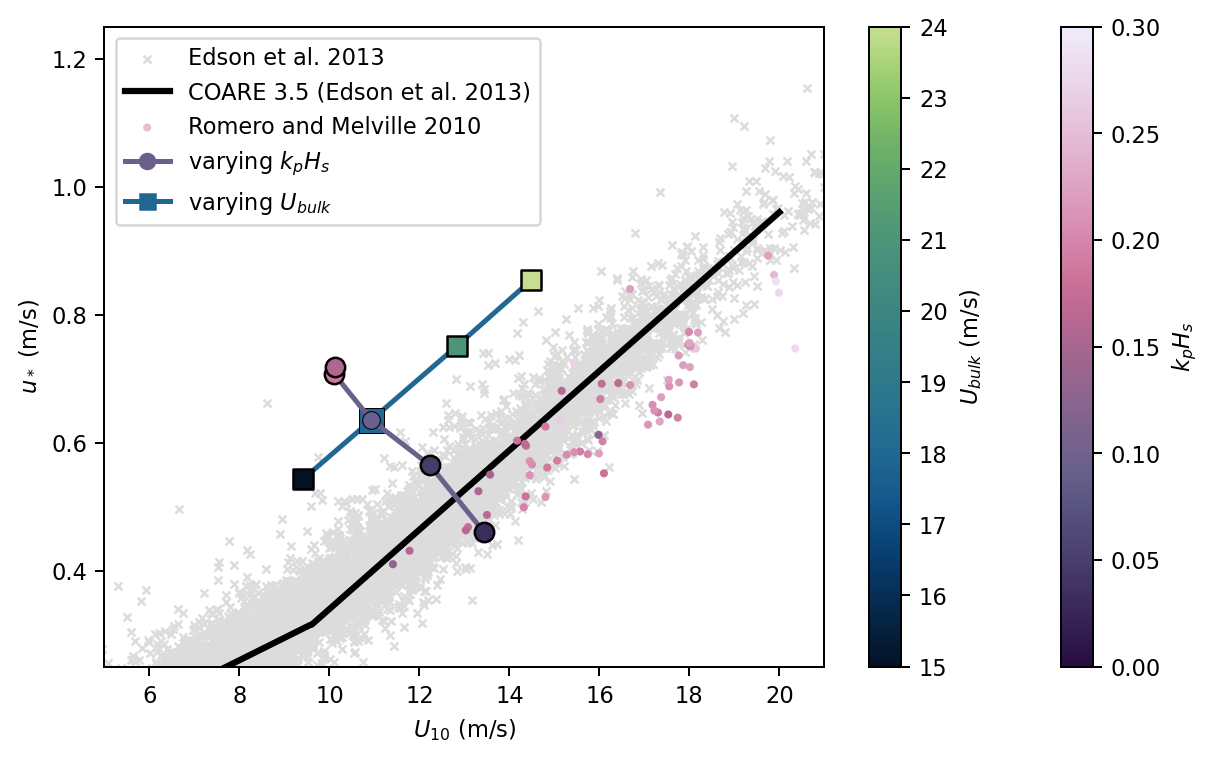

In [14]:
lw=2
dotsize=60
rcParams.update({'font.size': 9})

fig, ax = coare_plot_starter(figsize=(7, 4.3), Romero_colorby='kphs', 
                             Romero_cmap=wave_cmap)

# * plot wave
wave_norm = mpl.colors.Normalize(vmin=0, vmax=0.3)
ax.plot(wave_u10s, wave_ustars, color=wave_cmap(wave_norm(wave_colors[2])), lw=lw, zorder=5, ls='-',
        label=r'varying $k_pH_s$', marker='o')
for i, (x, y) in enumerate(zip(wave_u10s, wave_ustars)):
    if i == 2:
        ax.scatter(x, y, c=wave_colors[i], marker='o', edgecolors='black', s=dotsize-10, lw=0.4, zorder=6,
                   cmap=wave_cmap, vmin=0, vmax=0.3)
    else:    
        ax.scatter(x, y, c=wave_colors[i], marker='o', edgecolors='black', s=dotsize, lw=1, zorder=6,
                   cmap=wave_cmap, vmin=0, vmax=0.3)


# * plot wind
windmin, windmax = (15,24)
wind_norm = mpl.colors.Normalize(vmin=windmin, vmax=windmax)
ax.plot(wind_u10s, wind_ustars, color=wind_cmap(wind_norm(wind_colors[1])), lw=lw, zorder=3, ls='-',
        label=r'varying $U_{bulk}$', marker='s')
for i, (x, y) in enumerate(zip(wind_u10s, wind_ustars)):
    if i == 1:
        ax.scatter(x, y, c=wind_colors[i], marker='s', edgecolors='black', s=dotsize+40, lw=0.4, zorder=4,
                   cmap=wind_cmap, vmin=windmin, vmax=windmax)
    else:    
        sc = ax.scatter(x, y, c=wind_colors[i], marker='s', edgecolors='black', s=dotsize, lw=1, zorder=4,
                   cmap=wind_cmap, vmin=windmin, vmax=windmax)
plt.colorbar(sc, label=r"$U_{bulk}$ (m/s)")

# * other plot logistics
ax.set_xlim((5, 21))
ax.set_ylim((0.25,1.25))
ax.legend()

# fig.execute_constrained_layout()
fig.tight_layout()

fig.savefig('figures/slip_coare_kphs.pdf')


plot velocities just to get the velocity data (bulk, at 1000m)

U15
U(20): 10.6

U18
U(20): 12.3

U21
U(20): 14.4

U24
U(20): 16.3

hs04
U(20): 14.2

kp04
U(20): 13.3

mid
U(20): 12.3

kp16
U(20): 11.7

hs20
U(20): 11.8



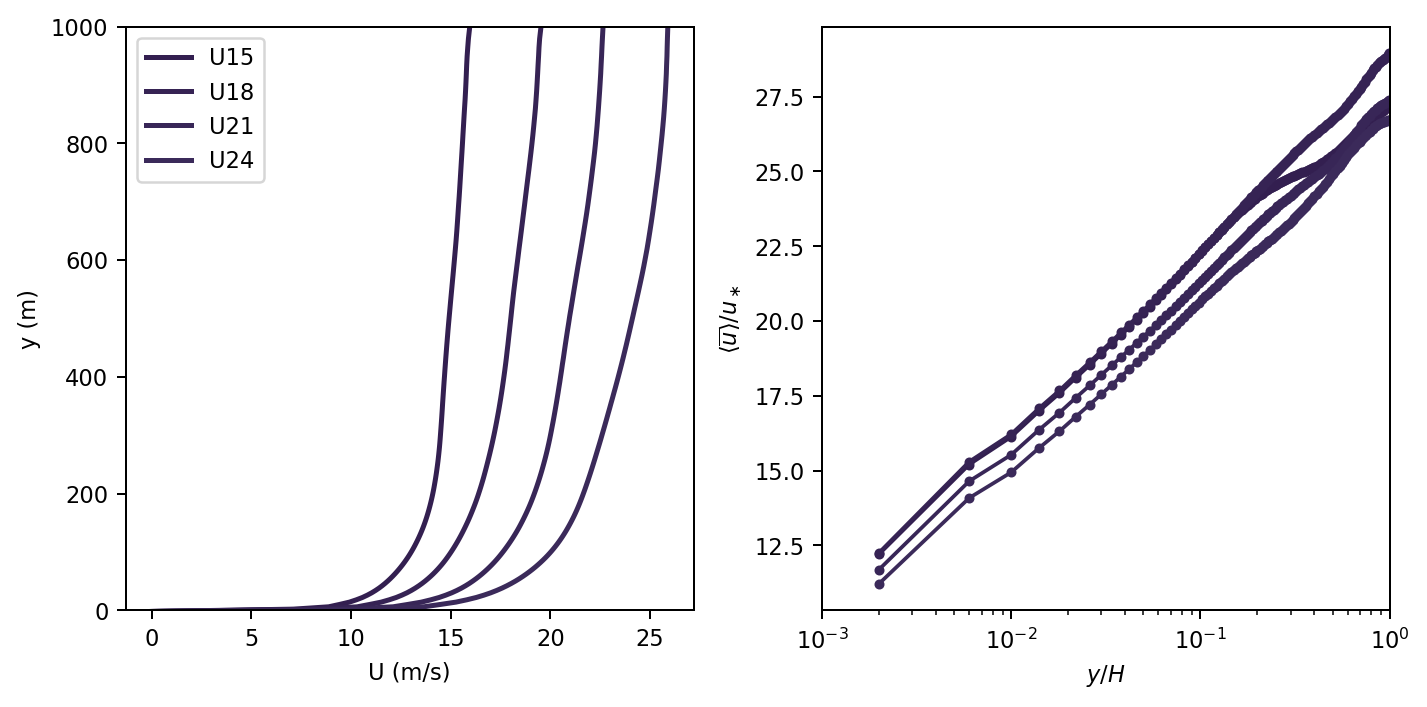

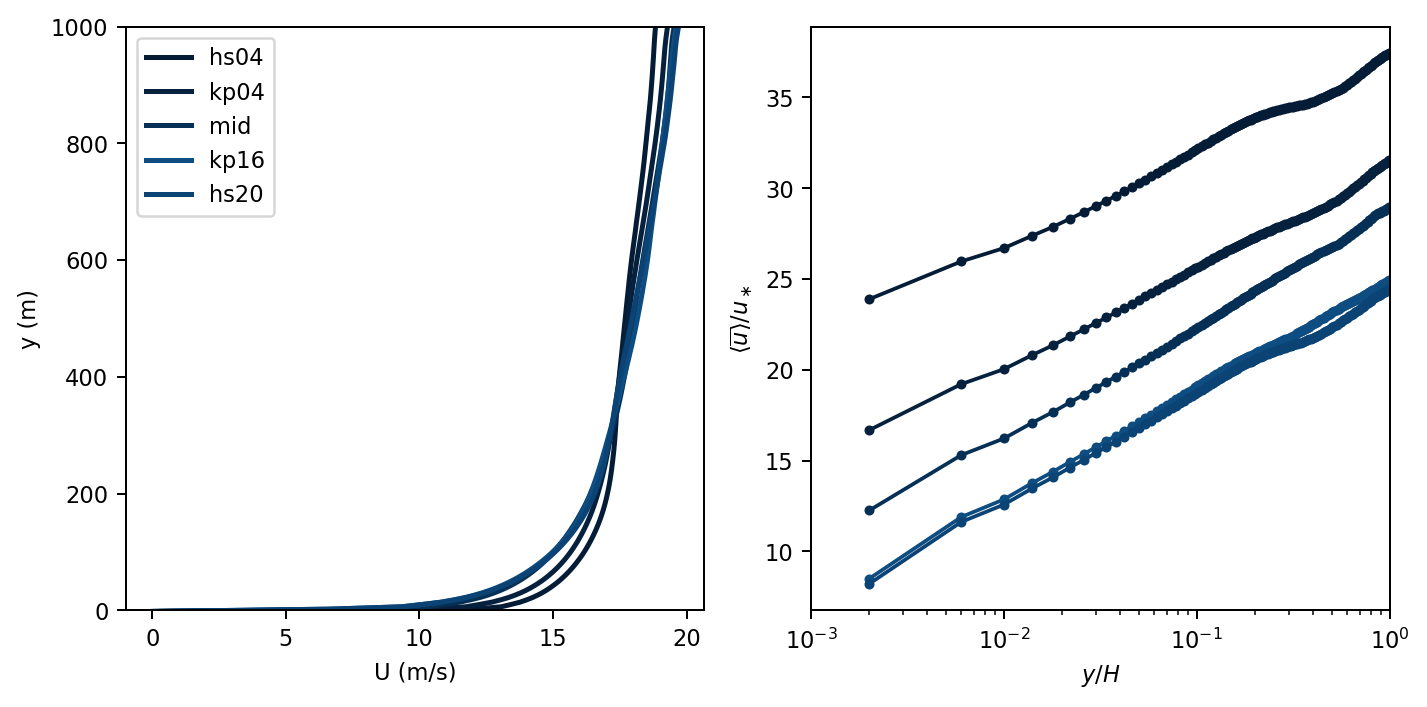

In [13]:
plot_velocity(wind_stats, wind_ids, cmc.acton(wind_colors))
plot_velocity(wave_stats, wave_ids, cmc.navia(wave_colors))

### plot z0 over $k_pH_s$

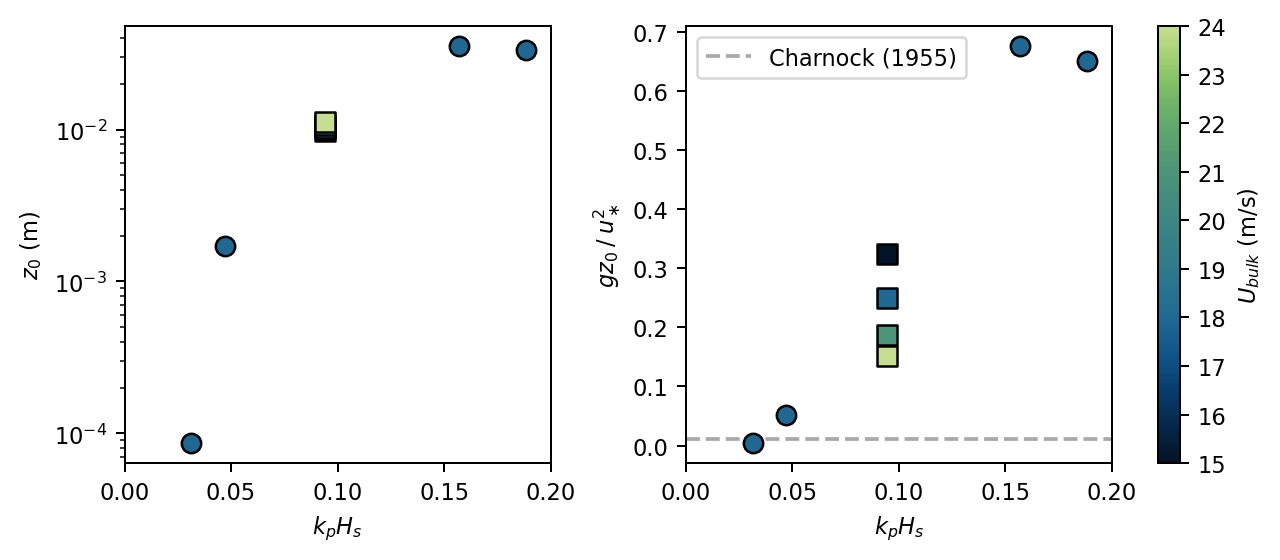

In [12]:
z_us = [10] #[0, 100]
wave_ustars = [stat.flux_ustar(z_us) for stat in wave_stats.values()]

rcParams.update({'font.size': 9})
fig, axs = plt.subplots(1,2,figsize=(7,3),constrained_layout=True, dpi=180.0)
# plt.subplots_adjust(wspace=0.4, top=0.98)

# * plot parameters
lw=2
dotsize=60
windmin, windmax = (15,24)
wind_norm = mpl.colors.Normalize(vmin=windmin, vmax=windmax)

# * wave sweeps
for i, (u10, us) in enumerate(zip(wave_u10s, wave_ustars)):
    x = wave_colors[i]
    ax0_y = z0(u10, us)
    ax1_y = 9.81*z0(u10,us)/us**2
    if i == 2:
        axs[0].scatter(x, ax0_y, 
                       color=wind_cmap(wind_norm(wind_colors[1])),
                   marker='o', edgecolors='black', s=dotsize-10, lw=0.4, zorder=4)
        axs[1].scatter(x, ax1_y,
                       color=wind_cmap(wind_norm(wind_colors[1])),
                   marker='o', edgecolors='black', s=dotsize-10, lw=0.4, zorder=4)
    else:
        axs[0].scatter(x, ax0_y, 
                       color=wind_cmap(wind_norm(wind_colors[1])),
                   marker='o', edgecolors='black', s=dotsize, lw=1, zorder=4)    
        axs[1].scatter(x, ax1_y,
                       color=wind_cmap(wind_norm(wind_colors[1])),
                   marker='o', edgecolors='black', s=dotsize, lw=1, zorder=4)
        
# * wind sweep
for i, (u10,us) in enumerate(zip(wind_u10s, wind_ustars)):  
    x = wave_colors[2]
    ax0_y = z0(u10,us)
    ax1_y = 9.81*z0(u10,us)/us**2
    axs[0].scatter(x, ax0_y,
                   c=wind_colors[i], marker='s', edgecolors='black', s=dotsize, lw=1, zorder=6,
                cmap=wind_cmap, vmin=windmin, vmax=windmax)
    sc = axs[1].scatter(x, ax1_y,
                        c=wind_colors[i], marker='s', edgecolors='black', s=dotsize, lw=1, zorder=6,
                cmap=wind_cmap, vmin=windmin, vmax=windmax)
        
plt.colorbar(sc, label=r"$U_{bulk}$ (m/s)")

# * Add Charnock and Edson '13 linear fit
axs[1].axhline(0.011, color='darkgray', ls='--', label='Charnock (1955)', zorder=1)
# kphses = np.linspace(0, 0.2, 2)
# axs[1].plot(kphses, kphses*0.09, color='darkgray', ls='-', label='Edson et al. 2013', zorder=1)

axs[1].legend()
axs[1].set_xlim((0, 0.2))

axs[0].set_ylabel(r'$z_0$ (m)')
axs[1].set_ylabel(r'$gz_0 \: / \: u_\ast^2$')

axs[0].set_yscale('log')

for i in range(len(axs)):
    axs[i].set_xlabel(r'$k_pH_s$')
    # axs[i].set_yscale('log')
    axs[i].set_xticks(np.linspace(0, 0.2, 5))

# fig.tight_layout(pad=3)

plt.savefig('figures/z0_over_kphs.pdf')

# Parameter sweep ($Hs$) with pressure gradient

In [8]:
pg_cases = ['pgrad_HS04', 'pgrad_HS12', 'pgrad_HS20']

caseids = [case+'/'+case for case in pg_cases]

ids = pg_cases

case_info = pd.read_excel('data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

pgstatlist = make_statlist(caseids, ids, case_info)

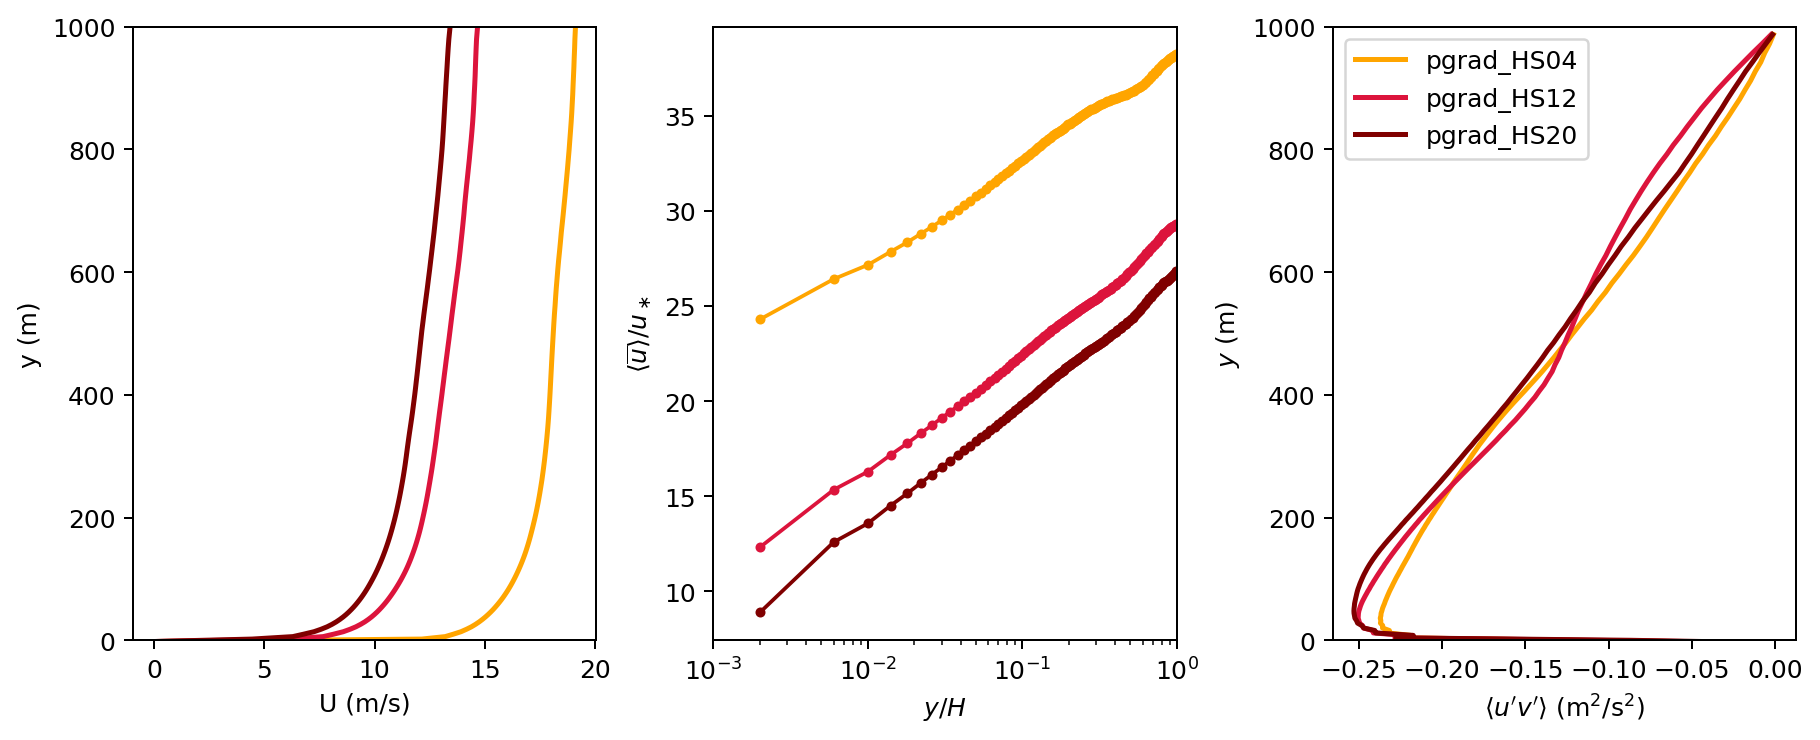

In [22]:
fig, axs = plt.subplots(1, 3, facecolor='w', dpi=180, constrained_layout=True,
                                figsize=(10,4))

colors = ['orange', 'crimson', 'maroon']

plot_velocity(pgstatlist, ids, colors, axs=axs[0:2], labels=False)
plot_upvp(pgstatlist, ids, colors, ax=axs[2], labels=True)

/tmp/ipykernel_2492637/1758345651.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=10, marker='x', lw=1,


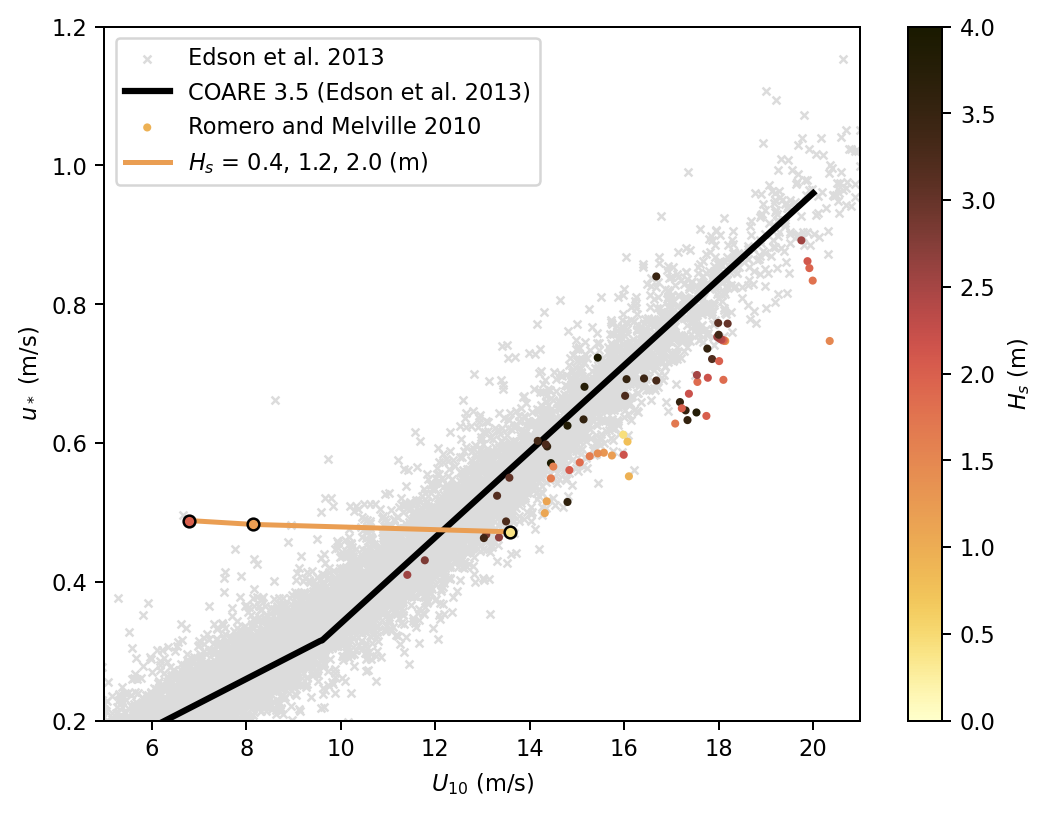

In [13]:
rcParams.update({'font.size': 9})
hs_cmap = cmc.lajolla_r

fig, ax = coare_plot_starter(figsize=(6,4.6), Romero_cmap=hs_cmap, Romero_colorby='hs')
lw=2
z_us = [0,200]

# * Hs
# hs_colors = ['lightcoral','firebrick', 'maroon']
# hs_cmap = cm.get_cmap('Reds')
hs_vals = [0.4, 1.2, 2.0]
hs_ustars = [stat.flux_ustar(z_us) for stat in pgstatlist.values()]
hs_u10s = [stat.Uz(10) for stat in pgstatlist.values()]

ax.plot(hs_u10s, hs_ustars, color=hs_cmap(hs_vals[1]/4), lw=lw, zorder=3, label=r'$H_s$ = 0.4, 1.2, 2.0 (m)')
for i, (x, y) in enumerate(zip(hs_u10s, hs_ustars)):
    # if i == 1:
    #     ax.scatter(x, y, c=hs_vals[i], marker='o', edgecolors='black', s=8, lw=0.4, zorder=4,
    #                cmap='Reds', vmin=0, vmax=4)
    # else:    
    ax.scatter(x, y, c=hs_vals[i], marker='o', edgecolors='black', s=22, lw=1, zorder=4,
                cmap=hs_cmap, vmin=0, vmax=4)
        

ax.legend()

ax.set_xlim((5, 21))
ax.set_ylim((0.2,1.2))

fig.savefig('figures/slip_coare_pgrad.pdf')